In [1]:
import pandas as pd
from tabulate import tabulate

# Load data
df1 = pd.read_csv('policy_platforms.csv')
df2 = pd.read_csv('biographical_narratives.csv')

# Merge keys
merge_keys = ['candidate_webname', 'year']

# Identify columns unique to df2 (excluding merge keys)
df1_cols = set(df1.columns)
df2_cols = set(df2.columns)
only_in_df2 = list(df2_cols - df1_cols - set(merge_keys))

# Extract only the unique info from df2
df2_unique = df2[merge_keys + only_in_df2].drop_duplicates(subset=merge_keys)

# Merge into df1 — will replicate bio info across all matching policy rows
df1_merged = df1.merge(df2_unique, on=merge_keys, how='left')

print("✅ Merge complete.")
print("🧾 Rows in DF1 before merge:", len(df1))
print("🧾 Rows in DF1 after merge :", len(df1_merged))

df_2018 = df1_merged[df1_merged['year'] == 2018]
df_2020 = df1_merged[df1_merged['year'] == 2020]
df_2022 = df1_merged[df1_merged['year'] == 2022]

print(len(df_2018))
print(len(df_2020))
print(len(df_2022))

total_original = len(df1_merged)
total_split = len(df_2018) + len(df_2020) + len(df_2022)

print("✅ Total original rows:", total_original)
print("✅ Total after split   :", total_split)

# Confirm all rows are accounted for
if total_original == total_split:
    print("✅ All rows accounted for.")
else:
    print("⚠️  Mismatch! Some rows may be missing.")


✅ Merge complete.
🧾 Rows in DF1 before merge: 43465
🧾 Rows in DF1 after merge : 43465
15576
14037
13852
✅ Total original rows: 43465
✅ Total after split   : 43465
✅ All rows accounted for.


2018 Graph: 1499 nodes, 312 edges
2020 Graph: 1447 nodes, 374 edges
2022 Graph: 1558 nodes, 282 edges


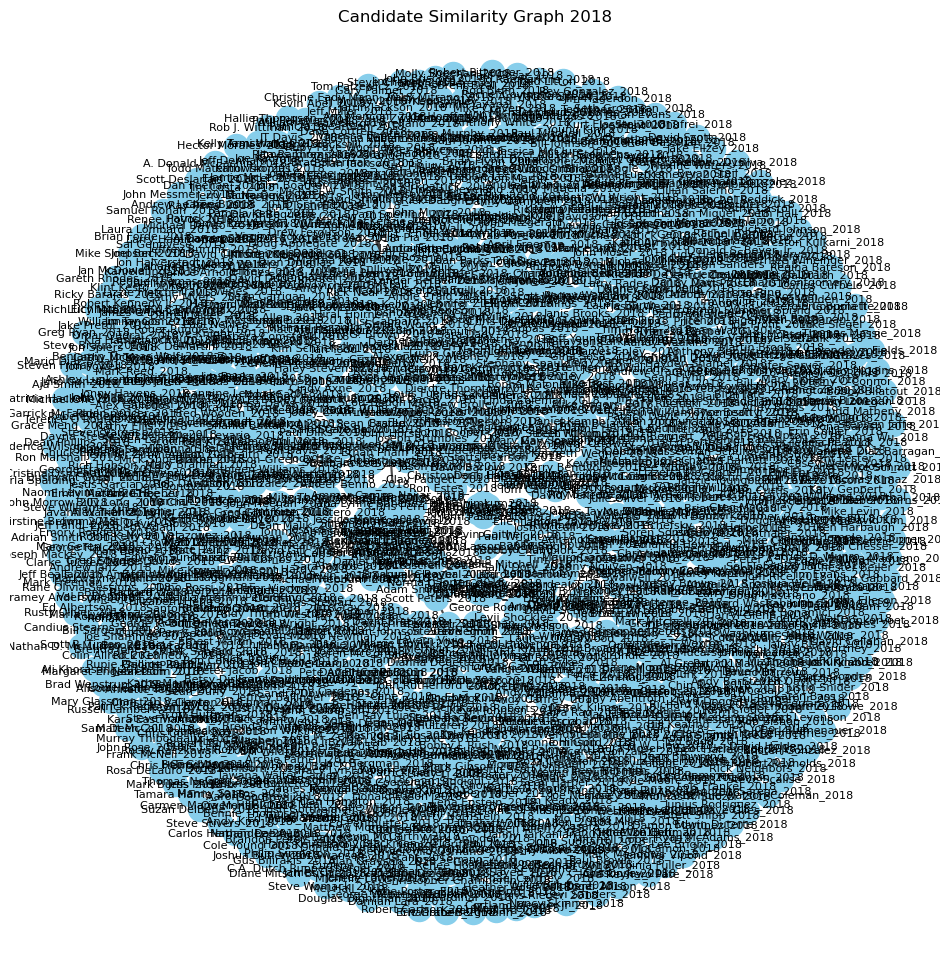

In [ ]:
import pandas as pd

# Assuming df1_merged has the relevant columns

df1_merged['combined_issues'] = (
    df1_merged['issue_header'].fillna('') + ' ' +
    df1_merged['issue_text'].fillna('') + ' ' +
    df1_merged['policy_code'].fillna('')
)

candidate_issues = df1_merged.groupby(['candidate_webname', 'year'])['combined_issues'].apply(lambda texts: ' '.join(texts)).reset_index()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

def build_similarity_graph(df, year, threshold=0.3):
    # Filter candidates from that year
    year_df = df[df['year'] == year].reset_index(drop=True)
    
    # Vectorize combined issues text
    vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
    tfidf_matrix = vectorizer.fit_transform(year_df['combined_issues'])
    
    # Compute cosine similarity (square matrix)
    sim_matrix = cosine_similarity(tfidf_matrix)
    
    # Build graph
    G = nx.Graph()
    
    # Add nodes: candidate names with year as suffix to avoid ambiguity
    nodes = [f"{row['candidate_webname']}_{row['year']}" for _, row in year_df.iterrows()]
    G.add_nodes_from(nodes)
    
    # Add edges where similarity > threshold (excluding self-loops)
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            weight = sim_matrix[i, j]
            if weight > threshold:
                G.add_edge(nodes[i], nodes[j], weight=weight)
    
    return G

graph_2018 = build_similarity_graph(candidate_issues, 2018)
graph_2020 = build_similarity_graph(candidate_issues, 2020)
graph_2022 = build_similarity_graph(candidate_issues, 2022)

print(f"2018 Graph: {graph_2018.number_of_nodes()} nodes, {graph_2018.number_of_edges()} edges")
print(f"2020 Graph: {graph_2020.number_of_nodes()} nodes, {graph_2020.number_of_edges()} edges")
print(f"2022 Graph: {graph_2022.number_of_nodes()} nodes, {graph_2022.number_of_edges()} edges")

import matplotlib.pyplot as plt

def plot_graph(G, title):
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, k=0.1)  # Layout adjustment
    weights = [G[u][v]['weight'] for u,v in G.edges()]
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='skyblue')
    nx.draw_networkx_edges(G, pos, width=[w*3 for w in weights], alpha=0.7)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_graph(graph_2018, "Candidate Similarity Graph 2018")
